# Example Iterative Sense with regularization

In [1]:
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq
import numpy as np
import requests
import mrpro
import matplotlib.pyplot as plt

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
# Load data from Pulseq file using KTrajectoryPulseq
# Local path
h5_path = '/data/bouill01/conda_envs/mrpro/examples/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds/pulseq_spiral_2D_220k0_128interleaves_golden_angle_vds_with_traj.h5'
seq_path = '/data/bouill01/conda_envs/mrpro/examples/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds.seq'
kdatapuls = KData.from_file(h5_path, KTrajectoryPulseq(seq_path=seq_path))



In [2]:
# Example function to calculate Gaussian filter based on trajectory
def radius_filter(traj_kx, traj_ky, sigma):
    # Calculate the radius based on the k-space trajectory
    radius = np.sqrt(traj_kx**2 + traj_ky**2)
    
    # Normalize radius to the range [0, 1]
    radius_normalized = radius / np.max(radius)
    
    # Calculate the Gaussian filter based on the normalized radius
    filt_weights = np.exp(-(radius_normalized**2) / (2 * sigma**2))
    
    return filt_weights

In [3]:
from mrpro.data import KData, KTrajectory
from mrpro.data.traj_calculators import KTrajectoryPulseq
import matplotlib.pyplot as plt
import numpy as np

def shift_k_space_trajectory(kdatapuls):
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices-1):
        # Calculate the shift for the current index
        shifted_ky[:,:,i,:] -= ky_pulseq[:,:,i,0]
        shifted_kx[:,:,i,:] -= kx_pulseq[:,:,i,0]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

In [4]:
from mrpro import algorithms
shifted_kdatapuls = shift_k_space_trajectory(kdatapuls)

sigma = 0.1
shifted_kdatapuls = shift_k_space_trajectory(kdatapuls)
gauss_filter = radius_filter(shifted_kdatapuls.traj.kx.numpy(), shifted_kdatapuls.traj.ky.numpy(), sigma)

# Adjust the filter shape to match the k-space data shape
gauss_filter_expanded = gauss_filter[None  ,:,:] # Expand dimensions to match k-space data shape

print(f"Expanded Gaussian filter shape: {gauss_filter_expanded.shape}")
print(f"K-space data shape: {shifted_kdatapuls.data.shape}")

# Apply the filter to the k-space data
kspace_data_lowpass = shifted_kdatapuls.data * gauss_filter_expanded

kdata_lowpass = KData(
    data=kspace_data_lowpass,  
    traj=shifted_kdatapuls.traj, 
    header=shifted_kdatapuls.header 
)

# Perform the Direct reconstruction with the low-pass filtered k-space data
reconstruction_lowpass = algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_lowpass, noise=None, coil_combine=True)
x_0_lowpass = reconstruction_lowpass(kdata_lowpass).data

Expanded Gaussian filter shape: (1, 1, 1, 128, 220)
K-space data shape: torch.Size([1, 16, 1, 128, 220])


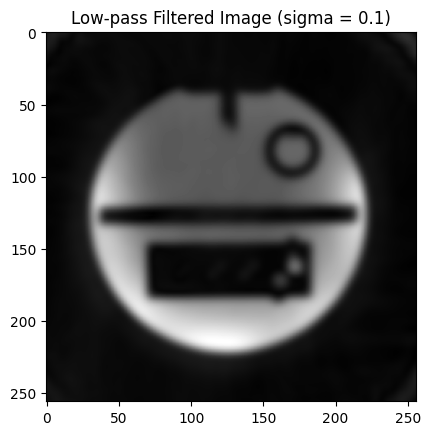

In [5]:
# Plot low-pass filtered image
plt.imshow(torch.abs(x_0_lowpass[0, 0, 0, :, :]), cmap='gray')
plt.title(f'Low-pass Filtered Image (sigma = {sigma})')
plt.show()

In [6]:
iterative_sense_reconstruction = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(
    shifted_kdatapuls, n_max_iter=10, lambda_value=0.1 , x0= x_0_lowpass
)
img = iterative_sense_reconstruction(shifted_kdatapuls)

TypeError: Can't instantiate abstract class LambdaOp with abstract methods adjoint, forward